# Juzgando por la portada 

Este notebook pretende mostrar la implementación y funcionamiento del proyecto *Juzgando por la portada* de la asignatura de Procesamiento de Imágenes Digitales (PID) de la Universidad de Sevilla. 

## Pasos previos
Si pretendes ejecutar este notebook, se recomienda encarecidamente usar CUDA para poder habilitar el entrenamiento con la GPU.
CUDA tiene que estar instalado de antemano.

TODO: actualizar 

> NOTA: se recomienda encarecidamente usar Linux directamente debido a las conocidas complicaciones de usar CUDA en Windows. Si aun así el usuario quisiera seguir usando Windows, se anima al usuario a encontrar soluciones y/o vías alternativas en foros o guías por su propia cuenta. 

# Imports

En esta celda puedes encontrar TODOS los imports que vas a necesitar a lo largo del notebook, asegúrate de que esta celda corre correctamente para evitar problemas futuros en la ejecución del notebook.

In [ ]:
import os
import itertools
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from IPython.display import clear_output
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array

I0000 00:00:1774091724.804770    1120 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774091725.587864    1120 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774091727.843406    1120 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Datos
En esta celda podemos ver la definición de ciertos parámetros importantes (como IMG_SIZE, RANDOM_SEED o MAX_EPOCHS). Además, limpiamos y preparamos los conjuntos de entrenamiento y validación y preprocesamos las imágenes haciendo un reescalado para reducir la resolución y optimizar el tiempo de entrenamiento. 

In [ ]:
# Configuración de entrenamiento
CSV_PATH = "../scripts/movies_preprocesado.csv"
IMG_SIZE = (192, 288)  # (alto, ancho)
BATCH_SIZE = 32
MAX_EPOCHS = 25
RANDOM_SEED = 42

df = pd.read_csv(CSV_PATH)

# Las primeras dos columnas son 'title' y 'poster_path', por lo que los géneros empiezan desde la columna 2 en adelante
genre_columns = df.columns[2:]

# El poster_path es el nombre de archivo, por lo que tomamos poster_path y lo convertimos a rutas completas
image_paths_base = df['poster_path'].apply(
    lambda x: os.path.join("../imagenes", str(x).lstrip('/'))
).values


# FILTRO: mantener solo imágenes existentes
print("\nVerificando qué imágenes existen...")
valid_indices = [idx for idx, path in enumerate(image_paths_base) if os.path.exists(path)]

print(f"Total imágenes en CSV: {len(image_paths_base)}")
print(f"Imágenes que existen: {len(valid_indices)}")
if len(valid_indices) > 0:
    missing = len(image_paths_base) - len(valid_indices)
    print(f"Imágenes faltantes: {missing}")
else:
    print("ADVERTENCIA: No se encontraron imágenes.")
    print("Asegúrate de haber ejecutado primero: python scripts/descarga_imagenes.py")

image_paths = image_paths_base[valid_indices]
y = df[genre_columns].values[valid_indices].astype('float32')

if len(image_paths) == 0:
    raise ValueError("No hay imágenes disponibles para entrenar. Ejecuta el script de descarga primero.")

# Dividir en entrenamiento y validación (80-20)
X_train, X_val, y_train, y_val = train_test_split(
    image_paths, y, test_size=0.2, random_state=RANDOM_SEED
 )

print("\nDatos después del filtrado:")
print(f"Imágenes de entrenamiento: {len(X_train)}")
print(f"Imágenes de validación: {len(X_val)}")
print(f"Total usado para entrenar: {len(image_paths)}")
print(f"Géneros ({len(genre_columns)}): {genre_columns.tolist()}")
print(f"Resolución de entrada: {IMG_SIZE}")

# AUTOTUNE -> configura automáticamente el número de hilos para cargar y preprocesar datos en paralelo
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    # Lee la imagen desde el disco 
    image_bytes = tf.io.read_file(path)
    # Decodifica la imagen y lo convierte en un tensor de 3 canales (RGB)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    # Reescalado de la imagen
    image = tf.image.resize(image, IMG_SIZE, method='bilinear')
    # Normalización a [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(paths, labels, training=True):
    # Crea un dataset de TensorFlow a partir de las rutas y etiquetas
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    # Si estamos entrenando, barajamos el dataset para evitar patrones de orden
    if training:
        ds = ds.shuffle(min(len(paths), 10_000), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    # Aplicamos la función de carga y preprocesamiento en paralelo para acelerar el proceso
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    # Salta archivos corruptos sin detener el entrenamiento
    ds = ds.ignore_errors()  
    # Agrupamos en batches y prefetch para optimizar la alimentación de datos a la GPU
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)
    return ds

print("\nCreando datasets optimizados para GPU...")
train_dataset = make_dataset(X_train, y_train, training=True)
val_dataset = make_dataset(X_val, y_val, training=False)
print("OK: Datasets creados con map paralelo y prefetch")


Verificando qué imágenes existen...


KeyboardInterrupt: 

# Definición del modelo

Podemos observar que tenemos un modelo con 3 bloques, dos capas convolucionales con función de activación ReLU y MaxPooling, un tercer bloque con GAP y finalmente una última capa con función de activación sigmoide para tener una salida binaria multietiqueta. 

In [ ]:
def intersperse(list, delimiter):
    try:
        it = iter(iterable)
        yield next(it)
        for x in it:
            yield delimiter
            yield x
    except StopIteration:
        return

def createModel(convLayers=3, firstConvFilterCount=32, denseLayers=1, firstDenseNeuronCount=256):
    model = models.Sequential(
        [
            layers.Input(shape=(*IMG_SIZE, 3)),
        ]
        +
        # Capas convolucionales
        list(intersperse(
            # Cada capa convolucional tiene el doble de filtros de la anterior
            [layers.Conv2D(firstConvFilterCount * (2 ** i), (3, 3), padding='same', activation='relu')
            for i in range(0,convLayers)],
            # Between each is a MaxPooling2D layer
            layers.MaxPooling2D(2, 2)
        ))
        +
        # GAP final para reducir dimensionalidad
        [
            layers.GlobalAveragePooling2D(),
        ]
        +
        [ 
            # Cada capa densa tiene la mitad de filtros de la anterior
            layers.Dense(firstDenseNeuronCount * (2 ** -i), (3, 3), padding='same', activation='relu')
            for i in range(0,denseLayers)
        ]
        +
        # En mixed precision dejamos la salida en float32 para mayor estabilidad numérica (esto me lo ha dicho la IA¿?)
        [
            layers.Dense(len(genre_columns), activation='sigmoid', dtype='float32')
        ]
    )

    # Compilar el modelo
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()

    return model

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 96, 144, 24)    │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 48, 72, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 72, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 36, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 36, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 19)             │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,523 (263.76 KB)

 Trainable params: 67,523 (263.76 KB)

 Non-trainable params: 0 (0.00 B)

# Entrenamiento del modelo

Definimos 2 callbacks: 
* EarlyStopping: evitamos llevar a cabo más épocas de las necesarias (si en 3 épocas no se mejora (o empeora) el resultado, se termina el entrenamiento)
* ReduceLROnPlateau: permite ajustar la tasa de aprendizaje de forma automática, estableciendo un learning rate mínimo. 

In [ ]:
def train_model(model):
    # Entrenamiento del modelo
    steps_per_epoch = max(1, int(np.ceil(len(X_train) / BATCH_SIZE)))
    validation_steps = max(1, int(np.ceil(len(X_val) / BATCH_SIZE)))

    # EarlyStopping para evitar sobreajuste y ReduceLROnPlateau para ajustar la tasa de aprendizaje automáticamente
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        # ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ]

    history = model.fit(
        train_dataset,
        steps_per_epoch=steps_per_epoch,
        epochs=MAX_EPOCHS,
        validation_data=val_dataset,
        validation_steps=validation_steps,
        callbacks=callbacks,
        verbose=2
    )

    print("Entrenamiento completado")
    print(f"Epocas entrenadas: {len(history.history['loss'])}")
    print(f"Val loss final: {history.history['val_loss'][-1]:.4f}")

    return history

Entrenamiento completado
Epocas entrenadas: 22
Val loss final: 0.2229


# Representación de los resultados

Podemos observar una gráfica que muestra la diferencia de precisión entre el conjunto de entrenamiento y el de validación y una segunda gráfica que muestra la diferencia de pérdida entre el conjunto de entrenamiento y el de validación. 

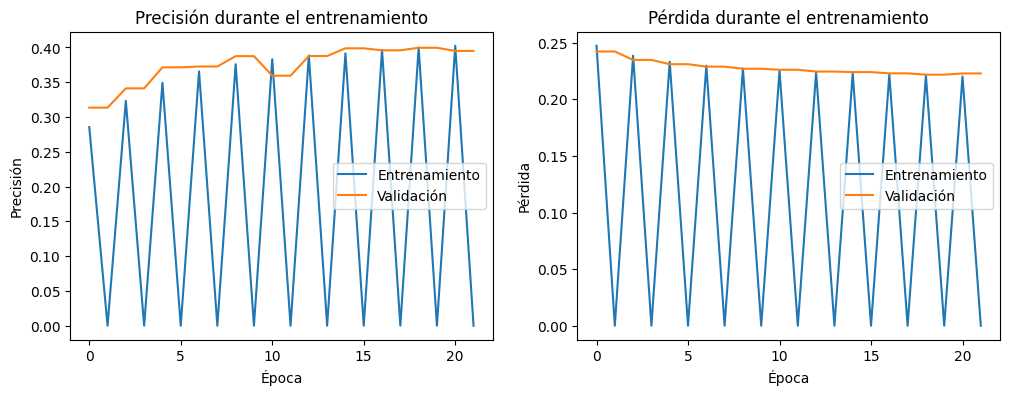

In [ ]:
def represent_data(history):
    plt.figure(figsize=(12, 4))

    # Gráfica de precisión
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Precisión durante el entrenamiento')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()

    # Gráfica de pérdida
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title('Pérdida durante el entrenamiento')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()

    plt.show()

# Métricas de evaluación

Evaluamos el modelo con las siguientes métricas:
* Exact Match Ratio: porcentaje de muestras en las que el conjunto de géneros predicho coincide exactamente con el conjunto real.
* Precision: de todas las etiquetas que el modelo marca como positivas, qué proporción era correcta (menos falsos positivos).
* Recall: de todas las etiquetas realmente positivas, qué proporción detecta el modelo (menos falsos negativos).
* F1 Score: media armónica entre precision y recall; resume el equilibrio entre ambas.

* Micro: calcula la métrica sumando primero los aciertos/errores de todas las clases; da más peso a las clases frecuentes.
* Macro: calcula la métrica por clase y luego promedia; da el mismo peso a todas las clases, incluso a las menos frecuentes.

In [ ]:
def evaluate_model(model):
    # Recolectar etiquetas reales directamente del dataset de validación
    y_val_filtered = np.concatenate([labels.numpy() for _, labels in val_dataset], axis=0)

    print(f"Etiquetas de validación usadas en evaluación: {len(y_val_filtered)}")

    # Predicciones del modelo sobre el mismo dataset y binarización con umbral de 0.5
    y_pred = model.predict(val_dataset)
    y_pred_bin = (y_pred > 0.5).astype(int)

    # Exact Match Ratio
    exact_match = accuracy_score(y_val_filtered, y_pred_bin)

    # Métricas de clasificación micro y macro
    precision_micro = precision_score(y_val_filtered, y_pred_bin, average='micro', zero_division=0)
    recall_micro = recall_score(y_val_filtered, y_pred_bin, average='micro', zero_division=0)
    f1_micro = f1_score(y_val_filtered, y_pred_bin, average='micro', zero_division=0)

    precision_macro = precision_score(y_val_filtered, y_pred_bin, average='macro', zero_division=0)
    recall_macro = recall_score(y_val_filtered, y_pred_bin, average='macro', zero_division=0)
    f1_macro = f1_score(y_val_filtered, y_pred_bin, average='macro', zero_division=0)

    print("\n=== RESULTADOS DE EVALUACION ===")
    print(f"Exact Match Ratio: {exact_match:.4f}")
    print(f"Precision (Micro): {precision_micro:.4f}")
    print(f"Recall (Micro): {recall_micro:.4f}")
    print(f"F1 Score (Micro): {f1_micro:.4f}")
    print(f"Precision (Macro): {precision_macro:.4f}")
    print(f"Recall (Macro): {recall_macro:.4f}")
    print(f"F1 Score (Macro): {f1_macro:.4f}")

    return [exact_match, precision_micro, recall_micro, f1_micro, precision_macro, recall_macro, f1_macro]

Etiquetas de validación usadas en evaluación: 83186
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 47s 18ms/step

=== RESULTADOS DE EVALUACION ===
Exact Match Ratio: 0.1327
Precision (Micro): 0.5998
Recall (Micro): 0.1670
F1 Score (Micro): 0.2613
Precision (Macro): 0.4618
Recall (Macro): 0.0839
F1 Score (Macro): 0.1250


# Busqueda en cuadrícula

In [ ]:
RESULTS_DIR = "resultados_modelos"
os.makedirs(RESULTS_DIR, exist_ok=True)

def result_path(convLayers, firstConvFilterCount, denseLayers, firstDenseNeuronCount):
    return os.path.join(RESULTS_DIR, f"conv{convLayers}_filters{firstConvFilterCount}_dense{denseLayers}_neurons{firstDenseNeuronCount}.txt")

def save_result(path, model, hyperparams, metrics):
    with open(path, "w") as f:
        f.write("=== HIPERPARÁMETROS ===\n")
        for k, v in hyperparams.items():
            f.write(f"  {k}: {v}\n")
        f.write("\n=== MÉTRICAS ===\n")
        for k, v in metrics.items():
            f.write(f"  {k}: {v:.4f}\n")

    keras_path = path.replace(".txt", ".keras")
    model.save(keras_path)


possibilities = [
    # Convolutional layers
    [2,3,4],
    # Filter count of first convolutional layer
    [32,64]
    # Dense layers
    [1,2]
    # Neuron count of first dense neuron
    [256,512]
]

permutations = list(itertools.product(*possibilities))

for [convLayers, firstConvFilterCount, denseLayers, firstDenseNeuronCount] in permutations:
    print("Entrenando modelo con: ")
    print(f" - Capas convolucionales: {convLayers}")
    print(f" - Cantidad de filtros en la primera capa convolucional: {firstConvFilterCount}")
    print(f" - Capas densas: {denseLayers}")
    print(f" - Cantidad de neuronas en la primera capa densa: {firstDenseNeuronCount}")
    
    path = result_path(convLayers, firstConvFilterCount, denseLayers, firstDenseNeuronCount)

    if os.path.exists(path):
        print(f"Saltando {os.path.basename(path)} (ya entrenado)")
        continue

    model = createModel(convLayers, firstConvFilterCount, denseLayers, firstDenseNeuronCount)
    history = train_model(model)
    represent_data(history)
    [exact_match, precision_micro, recall_micro, f1_micro, precision_macro, recall_macro, f1_macro] = evaluate_model(model)

    save_result(path,
        model,
        {
            "convLayers": convLayers,
            "firstConvFilterCount": firstConvFilterCount,
            "denseLayers": denseLayers,
            "firstDenseNeuronCount": firstDenseNeuronCount,
        },
        {
            "exact_match": exact_match,
            "precision_micro": precision_micro,
            "recall_micro": recall_micro,
            "f1_micro": f1_micro,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "f1_macro": f1_macro,
        }
    )
    

# Ejemplo de funcionamiento

En la siguiente celda podemos observar cómo funciona el modelo, junto a las etiquetas predichas y la etiqueta real. Se muestra también las mejores 5 predicciones. 

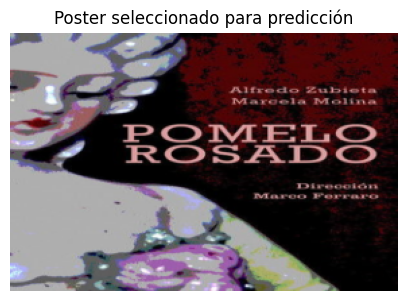

=== PREDICCION DEL MODELO ===
Imagen: ../imagenes/hItbb6JvL8Ugl5b5osYab3e4Jrh.jpg
Géneros reales: ['Thriller']
Géneros predichos (umbral=0.5): ['Documentary']

Top-5 probabilidades:
  - Documentary: 0.4286
  - Music: 0.2363
  - Drama: 0.2279
  - Animation: 0.1209
  - Horror: 0.1128


In [ ]:
# Umbral para convertir probabilidad a etiqueta positiva
PRED_THRESHOLD = 0.5

def predict_single_image(image_path, true_label=None, threshold=PRED_THRESHOLD):
    img = load_img(image_path, target_size=IMG_SIZE, interpolation='bilinear')
    img_array = img_to_array(img) / 255.0
    input_batch = np.expand_dims(img_array, axis=0)

    pred_probs = model.predict(input_batch, verbose=0)[0]
    pred_binary = (pred_probs >= threshold).astype(int)

    predicted_genres = genre_columns[pred_binary == 1].tolist()
    if len(predicted_genres) == 0:
        top_idx = int(np.argmax(pred_probs))
        predicted_genres = [genre_columns[top_idx]]

    sorted_idx = np.argsort(pred_probs)[::-1][:5]
    top5 = [(genre_columns[i], float(pred_probs[i])) for i in sorted_idx]

    true_genres = []
    if true_label is not None:
        true_genres = genre_columns[np.array(true_label) == 1].tolist()

    plt.figure(figsize=(5, 7))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Poster seleccionado para predicción')
    plt.show()

    print('=== PREDICCION DEL MODELO ===')
    print(f'Imagen: {image_path}')
    if true_label is not None:
        print(f'Géneros reales: {true_genres if true_genres else "Ninguno"}')
    print(f'Géneros predichos (umbral={threshold}): {predicted_genres}')
    print('\nTop-5 probabilidades:')
    for genre, prob in top5:
        print(f'  - {genre}: {prob:.4f}')

# Selecciona una imagen aleatoria del conjunto de validación
if len(X_val) == 0:
    raise ValueError('No hay imágenes en validación para mostrar predicciones.')

sample_idx = random.randrange(len(X_val))
sample_path = X_val[sample_idx]
sample_label = y_val[sample_idx]

predict_single_image(sample_path, true_label=sample_label, threshold=PRED_THRESHOLD)